# Google Colab: Custom Object Detection Training (YOLO)

This notebook trains a multi-class object detector (cars, phones, chairs, etc.) using Ultralytics YOLO with GPU acceleration.

Included:
- Drive mount + dataset loading from shared folder
- Auto dataset format handling (YOLO, VOC XML, COCO JSON)
- Validation for missing labels and corrupt images
- Train/val/test split
- Augmentation + mixed precision + early stopping
- Optional learning-rate sweep
- Evaluation (mAP, precision, recall, confusion matrix)
- Save best.pt to Drive and local download
- Inference on images and optional webcam capture

In [2]:
import sys, subprocess

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-U', *pkgs])

pip_install('ultralytics>=8.3.0', 'gdown', 'pyyaml', 'opencv-python-headless', 'pandas', 'seaborn')

import ultralytics, torch
print('ultralytics:', ultralytics.__version__)
print('torch:', torch.__version__)
print('cuda:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))

ultralytics: 8.4.37
torch: 2.10.0+cpu
cuda: False


In [3]:
from pathlib import Path
import os, re, json, random, shutil, time
from collections import Counter, defaultdict
import xml.etree.ElementTree as ET

import yaml
import numpy as np
import pandas as pd
from PIL import Image

from google.colab import drive, files
from ultralytics import YOLO

DRIVE_FOLDER_URL = 'https://drive.google.com/drive/folders/1MxYuNy3m_cpdzPeeLKlJyFYz6yf2UlWZ?usp=sharing'
LOCAL_DATASET_ROOT = None  # Example: '/content/drive/MyDrive/my_dataset'

WORK_DIR = Path('/content/custom_obj_project')
RAW_DIR = WORK_DIR / 'raw_data'
YOLO_DIR = WORK_DIR / 'prepared_yolo'
RUNS_DIR = WORK_DIR / 'runs'
EXPORT_ROOT = Path('/content/drive/MyDrive/object_detection_outputs')

SEED = 42
SPLIT = (0.8, 0.1, 0.1)
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
SPLIT_MAP = {'train': 'train', 'training': 'train', 'val': 'val', 'valid': 'val', 'validation': 'val', 'test': 'test'}

random.seed(SEED)
np.random.seed(SEED)
WORK_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print('WORK_DIR:', WORK_DIR)

WORK_DIR: /content/custom_obj_project


In [4]:
drive.mount('/content/drive', force_remount=False)

def folder_id(url):
    m = re.search(r'/folders/([A-Za-z0-9_-]+)', url)
    return m.group(1) if m else None

def shortcut_root(url):
    fid = folder_id(url)
    if not fid:
        return None
    p = Path('/content/drive/.shortcut-targets-by-id') / fid
    if not p.exists():
        return None
    children = [x for x in p.iterdir() if x.is_dir()]
    return children[0] if len(children) == 1 else p

DATA_ROOT = None

if LOCAL_DATASET_ROOT and Path(LOCAL_DATASET_ROOT).exists():
    DATA_ROOT = Path(LOCAL_DATASET_ROOT)

if DATA_ROOT is None:
    s = shortcut_root(DRIVE_FOLDER_URL)
    if s is not None:
        DATA_ROOT = s

if DATA_ROOT is None:
    if RAW_DIR.exists():
        shutil.rmtree(RAW_DIR)
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    cmd = ['gdown', '--folder', DRIVE_FOLDER_URL, '-O', str(RAW_DIR)]
    res = subprocess.run(cmd, check=False, text=True, capture_output=True)
    if res.stdout:
        print(res.stdout[-3000:])
    if res.stderr:
        print(res.stderr[-1500:])
    dirs = [d for d in RAW_DIR.iterdir() if d.is_dir()] if RAW_DIR.exists() else []
    DATA_ROOT = dirs[0] if len(dirs) == 1 else RAW_DIR

if DATA_ROOT is None or not DATA_ROOT.exists():
    raise FileNotFoundError('Dataset not found. Set LOCAL_DATASET_ROOT or add Drive shortcut.')

print('DATA_ROOT:', DATA_ROOT)
for i, p in enumerate(sorted(DATA_ROOT.iterdir(), key=lambda x: x.name.lower())[:60]):
    print(('[DIR] ' if p.is_dir() else '[FILE]') + p.name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_ROOT: /content/drive/.shortcut-targets-by-id/1MxYuNy3m_cpdzPeeLKlJyFYz6yf2UlWZ/Car-Person Custom-Object-Detection-v2-Roboflow
[FILE]data.yaml
[FILE]README.dataset.txt
[FILE]README.roboflow.txt
[DIR] test
[DIR] train
[DIR] valid


In [5]:
def is_img(p):
    return p.is_file() and p.suffix.lower() in IMAGE_EXTS

def split_from_path(p):
    for t in [x.lower() for x in p.parts]:
        if t in SPLIT_MAP:
            return SPLIT_MAP[t]
    return None

def yolo_rows(label_path):
    rows = []
    for ln in label_path.read_text(encoding='utf-8', errors='ignore').splitlines():
        sp = ln.strip().split()
        if len(sp) < 5:
            continue
        try:
            c = int(float(sp[0]))
            x, y, w, h = [float(v) for v in sp[1:5]]
        except Exception:
            continue
        x, y, w, h = [min(1.0, max(0.0, v)) for v in [x, y, w, h]]
        if w > 0 and h > 0:
            rows.append((c, x, y, w, h))
    return rows

def write_rows(path, rows):
    txt = '\n'.join([f"{c} {x:.6f} {y:.6f} {w:.6f} {h:.6f}" for c, x, y, w, h in rows])
    path.write_text((txt + '\n') if txt else '', encoding='utf-8')

def verify_img(path):
    try:
        with Image.open(path) as im:
            im.verify()
        return True
    except Exception:
        return False

def find_yaml_names(root):
    for y in list(root.rglob('*.yaml')) + list(root.rglob('*.yml')):
        try:
            d = yaml.safe_load(y.read_text(encoding='utf-8'))
            n = d.get('names') if isinstance(d, dict) else None
            if isinstance(n, list) and n:
                return [str(x) for x in n]
            if isinstance(n, dict) and n:
                return [str(v) for k, v in sorted(n.items(), key=lambda kv: int(kv[0]) if str(kv[0]).isdigit() else str(kv[0]))]
        except Exception:
            pass
    return None

def voc_to_rows(xml_path, cls_map):
    root = ET.parse(xml_path).getroot()
    size = root.find('size')
    if size is None:
        return []
    iw = float(size.findtext('width', '0'))
    ih = float(size.findtext('height', '0'))
    if iw <= 0 or ih <= 0:
        return []
    out = []
    for obj in root.findall('object'):
        name = obj.findtext('name', 'unknown').strip()
        if name not in cls_map:
            cls_map[name] = len(cls_map)
        bb = obj.find('bndbox')
        if bb is None:
            continue
        try:
            xmin = float(bb.findtext('xmin', '0'))
            ymin = float(bb.findtext('ymin', '0'))
            xmax = float(bb.findtext('xmax', '0'))
            ymax = float(bb.findtext('ymax', '0'))
        except Exception:
            continue
        xmin, ymin = max(0, xmin), max(0, ymin)
        xmax, ymax = min(iw, xmax), min(ih, ymax)
        bw, bh = xmax - xmin, ymax - ymin
        if bw <= 1 or bh <= 1:
            continue
        xc = ((xmin + xmax) / 2) / iw
        yc = ((ymin + ymax) / 2) / ih
        out.append((cls_map[name], xc, yc, bw / iw, bh / ih))
    return out

def parse_coco(json_path):
    d = json.loads(json_path.read_text(encoding='utf-8'))
    if not all(k in d for k in ['images', 'annotations', 'categories']):
        return None
    c2n = {int(c['id']): str(c['name']) for c in d['categories']}
    names = sorted(set(c2n.values()))
    n2i = {n: i for i, n in enumerate(names)}
    im_map = {int(im['id']): im for im in d['images']}
    ann_map = defaultdict(list)
    for a in d['annotations']:
        ann_map[int(a.get('image_id', -1))].append(a)
    by_file = {}
    for iid, im in im_map.items():
        iw, ih = float(im.get('width', 0)), float(im.get('height', 0))
        if iw <= 0 or ih <= 0:
            continue
        rows = []
        for a in ann_map.get(iid, []):
            bb = a.get('bbox', [])
            if len(bb) != 4:
                continue
            x, y, w, h = [float(v) for v in bb]
            if w <= 1 or h <= 1:
                continue
            cls_name = c2n.get(int(a.get('category_id', -1)))
            if cls_name is None:
                continue
            rows.append((n2i[cls_name], (x + w / 2) / iw, (y + h / 2) / ih, w / iw, h / ih))
        by_file[Path(im.get('file_name', '')).name] = rows
    return names, by_file

def prepare_dataset(src, out):
    if out.exists():
        shutil.rmtree(out)
    for s in ['train', 'val', 'test']:
        (out / 'images' / s).mkdir(parents=True, exist_ok=True)
        (out / 'labels' / s).mkdir(parents=True, exist_ok=True)

    imgs = sorted([p for p in src.rglob('*') if is_img(p)])
    if not imgs:
        raise FileNotFoundError('No images found.')

    # 1) Try YOLO labels
    items = []
    miss = 0
    for im in imgs:
        stem = im.stem
        cands = [im.with_suffix('.txt')]
        rel = im.relative_to(src).as_posix()
        if '/images/' in '/' + rel:
            cands.append((src / rel.replace('/images/', '/labels/')).with_suffix('.txt'))
        cands.append((src / 'labels' / im.relative_to(src)).with_suffix('.txt'))
        lbl = next((c for c in cands if Path(c).exists()), None)
        if lbl is None:
            miss += 1
            continue
        items.append({'img': im, 'rows': yolo_rows(lbl), 'split': split_from_path(im) or split_from_path(lbl)})

    fmt = None
    names = find_yaml_names(src)

    if items:
        fmt = 'yolo'
        if names is None:
            m = 0
            for it in items:
                for r in it['rows']:
                    m = max(m, int(r[0]))
            names = [f'class_{i}' for i in range(m + 1)]

    # 2) Try VOC
    if fmt is None:
        cls_map, voc_items = {}, []
        for im in imgs:
            stem = im.stem
            cands = [im.with_suffix('.xml'), src / 'annotations' / f'{stem}.xml']
            xmlp = next((c for c in cands if Path(c).exists()), None)
            if xmlp is None:
                continue
            voc_items.append({'img': im, 'rows': voc_to_rows(xmlp, cls_map), 'split': split_from_path(im) or split_from_path(xmlp)})
        if voc_items:
            fmt = 'voc'
            items = voc_items
            names = [n for n, _ in sorted(cls_map.items(), key=lambda kv: kv[1])]

    # 3) Try COCO
    if fmt is None:
        jfiles = sorted(src.rglob('*.json'))
        by_name = defaultdict(list)
        for im in imgs:
            by_name[im.name].append(im)
        coco_items = []
        for j in jfiles:
            parsed = None
            try:
                parsed = parse_coco(j)
            except Exception:
                parsed = None
            if parsed is None:
                continue
            names_tmp, by_file = parsed
            jsplit = split_from_path(j)
            for fn, rows in by_file.items():
                cand = by_name.get(fn, [])
                if not cand:
                    continue
                coco_items.append({'img': cand[0], 'rows': rows, 'split': split_from_path(cand[0]) or jsplit})
            if coco_items:
                fmt = 'coco'
                items = coco_items
                names = names_tmp
                break

    if fmt is None or not items:
        raise RuntimeError('No supported annotations found (YOLO/VOC/COCO).')

    # Image validation
    good, bad = [], 0
    for it in items:
        if verify_img(it['img']):
            good.append(it)
        else:
            bad += 1

    buckets = {'train': [], 'val': [], 'test': [], 'unspecified': []}
    for it in good:
        sp = it['split']
        if sp in ['train', 'val', 'test']:
            buckets[sp].append(it)
        else:
            buckets['unspecified'].append(it)

    random.shuffle(buckets['unspecified'])
    n = len(buckets['unspecified'])
    ntr, nva = int(n * SPLIT[0]), int(n * SPLIT[1])
    buckets['train'] += buckets['unspecified'][:ntr]
    buckets['val'] += buckets['unspecified'][ntr:ntr + nva]
    buckets['test'] += buckets['unspecified'][ntr + nva:]

    if len(buckets['val']) == 0 and len(buckets['train']) > 10:
        take = max(1, len(buckets['train']) // 10)
        buckets['val'] = buckets['train'][-take:]
        buckets['train'] = buckets['train'][:-take]

    if len(buckets['test']) == 0 and len(buckets['train']) > 10:
        take = max(1, len(buckets['train']) // 10)
        buckets['test'] = buckets['train'][-take:]
        buckets['train'] = buckets['train'][:-take]

    cls_count = Counter()
    copied = {'train': 0, 'val': 0, 'test': 0}

    for sp in ['train', 'val', 'test']:
        for i, it in enumerate(buckets[sp], 1):
            stem = f'{sp}_{i:06d}'
            img_dst = out / 'images' / sp / f'{stem}{it["img"].suffix.lower()}'
            lbl_dst = out / 'labels' / sp / f'{stem}.txt'
            shutil.copy2(it['img'], img_dst)
            write_rows(lbl_dst, it['rows'])
            for r in it['rows']:
                cls_count[int(r[0])] += 1
            copied[sp] += 1

    max_cls = max(cls_count.keys()) if cls_count else 0
    if names is None:
        names = [f'class_{i}' for i in range(max_cls + 1)]
    while len(names) <= max_cls:
        names.append(f'class_{len(names)}')

    yml = {
        'path': str(out.resolve()),
        'train': 'images/train',
        'val': 'images/val',
        'test': 'images/test',
        'nc': len(names),
        'names': names
    }
    yml_path = out / 'dataset.yaml'
    yml_path.write_text(yaml.safe_dump(yml, sort_keys=False), encoding='utf-8')

    stats = {
        'format': fmt,
        'images_scanned': len(imgs),
        'missing_labels_initial': int(miss),
        'corrupt_images_removed': int(bad),
        'split_counts': copied,
        'class_distribution': {names[k] if k < len(names) else f'class_{k}': int(v) for k, v in sorted(cls_count.items())}
    }
    return yml_path, names, stats

In [6]:
DATA_YAML, CLASS_NAMES, STATS = prepare_dataset(DATA_ROOT, YOLO_DIR)
print('DATA_YAML:', DATA_YAML)
print('CLASS_NAMES:', CLASS_NAMES)
print('STATS:')
for k, v in STATS.items():
    print('-', k, ':', v)
print('\n' + DATA_YAML.read_text(encoding='utf-8'))

DATA_YAML: /content/custom_obj_project/prepared_yolo/dataset.yaml
CLASS_NAMES: ['Mobile_phone']
STATS:
- format : yolo
- images_scanned : 4374
- missing_labels_initial : 0
- corrupt_images_removed : 0
- split_counts : {'train': 4116, 'val': 238, 'test': 20}
- class_distribution : {'Mobile_phone': 6288}

path: /content/custom_obj_project/prepared_yolo
train: images/train
val: images/val
test: images/test
nc: 1
names:
- Mobile_phone



train: images=4116, labels=4116
val: images=238, labels=238
test: images=20, labels=20


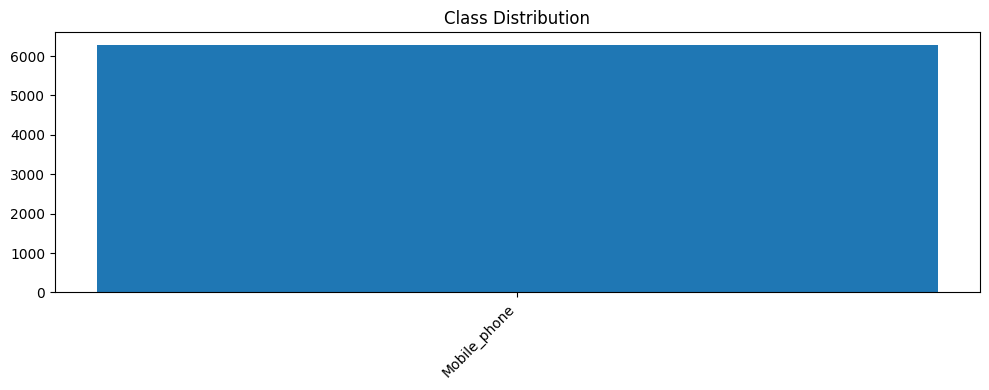

In [8]:
import matplotlib.pyplot as plt

for s in ['train', 'val', 'test']:
    ni = len([p for p in (YOLO_DIR / 'images' / s).glob('*') if p.suffix.lower() in IMAGE_EXTS])
    nl = len(list((YOLO_DIR / 'labels' / s).glob('*.txt')))
    print(f'{s}: images={ni}, labels={nl}')

dist = STATS.get('class_distribution', {})
if dist:
    ks = list(dist.keys())
    vs = [dist[k] for k in ks]
    plt.figure(figsize=(10,4))
    plt.bar(ks, vs)
    plt.title('Class Distribution')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
# Ensure every class is represented in the train split.
def label_class_set(label_path):
    out = set()
    for ln in label_path.read_text(encoding='utf-8', errors='ignore').splitlines():
        sp = ln.strip().split()
        if not sp:
            continue
        try:
            out.add(int(float(sp[0])))
        except Exception:
            pass
    return out

def class_names_from_yaml(yaml_path):
    y = yaml.safe_load(Path(yaml_path).read_text(encoding='utf-8'))
    names = y.get('names', []) if isinstance(y, dict) else []
    if isinstance(names, dict):
        names = [str(v) for _, v in sorted(names.items(), key=lambda kv: int(kv[0]) if str(kv[0]).isdigit() else str(kv[0]))]
    elif isinstance(names, list):
        names = [str(x) for x in names]
    else:
        names = []
    nc = int(y.get('nc', len(names))) if isinstance(y, dict) else len(names)
    while len(names) < nc:
        names.append(f'class_{len(names)}')
    return names, nc

def find_image_for_label(split, stem):
    img_dir = YOLO_DIR / 'images' / split
    for ext in IMAGE_EXTS:
        p = img_dir / f'{stem}{ext}'
        if p.exists():
            return p
    cands = sorted(img_dir.glob(f'{stem}.*'))
    return cands[0] if cands else None

def train_object_counts():
    counts = Counter()
    for lp in sorted((YOLO_DIR / 'labels' / 'train').glob('*.txt')):
        for ln in lp.read_text(encoding='utf-8', errors='ignore').splitlines():
            sp = ln.strip().split()
            if not sp:
                continue
            try:
                counts[int(float(sp[0]))] += 1
            except Exception:
                pass
    return counts

NAMES_FROM_YAML, NC = class_names_from_yaml(DATA_YAML)
expected_classes = set(range(NC))

split_labels = {s: sorted((YOLO_DIR / 'labels' / s).glob('*.txt')) for s in ['train', 'val', 'test']}
train_present = set()
for lp in split_labels['train']:
    train_present |= label_class_set(lp)

missing = sorted(expected_classes - train_present)
print('Total classes in dataset.yaml (nc):', NC)
print('Classes present in train before fix:', len(train_present))
if missing:
    print('Missing in train before fix:', [NAMES_FROM_YAML[i] if i < len(NAMES_FROM_YAML) else f'class_{i}' for i in missing])

moved = []
if missing:
    donor_pool = []
    for sp in ['val', 'test']:
        for lp in split_labels[sp]:
            donor_pool.append((sp, lp, label_class_set(lp)))

    for cls_id in missing[:]:
        pick = next((x for x in donor_pool if cls_id in x[2]), None)
        if pick is None:
            continue
        sp, src_label, _ = pick
        src_img = find_image_for_label(sp, src_label.stem)
        if src_img is None:
            continue

        dst_label = YOLO_DIR / 'labels' / 'train' / src_label.name
        dst_img = YOLO_DIR / 'images' / 'train' / src_img.name
        k = 1
        while dst_label.exists() or dst_img.exists():
            new_stem = f'{src_label.stem}_mv{k:03d}'
            dst_label = YOLO_DIR / 'labels' / 'train' / f'{new_stem}.txt'
            dst_img = YOLO_DIR / 'images' / 'train' / f'{new_stem}{src_img.suffix.lower()}'
            k += 1

        shutil.move(str(src_label), str(dst_label))
        shutil.move(str(src_img), str(dst_img))
        moved.append((cls_id, sp, dst_label.name))
        donor_pool = [x for x in donor_pool if not (x[0] == sp and x[1] == src_label)]

if moved:
    print('Moved samples into train to ensure class coverage:')
    for cls_id, from_split, fname in moved:
        cname = NAMES_FROM_YAML[cls_id] if cls_id < len(NAMES_FROM_YAML) else f'class_{cls_id}'
        print('-', cname, f'(id={cls_id}) from {from_split}:', fname)

train_present_after = set()
for lp in sorted((YOLO_DIR / 'labels' / 'train').glob('*.txt')):
    train_present_after |= label_class_set(lp)

missing_after = sorted(expected_classes - train_present_after)
if missing_after:
    missing_names = [NAMES_FROM_YAML[i] if i < len(NAMES_FROM_YAML) else f'class_{i}' for i in missing_after]
    raise RuntimeError(f'Train split still missing classes: {missing_names}. Add more labeled samples for these classes.')

counts = train_object_counts()
print('Classes present in train after fix:', len(train_present_after), '/', NC)
for i in range(NC):
    cname = NAMES_FROM_YAML[i] if i < len(NAMES_FROM_YAML) else f'class_{i}'
    print(f'{i:>3} {cname:<25} objects={counts.get(i, 0)}')

In [1]:
import gc
import os
import torch

HAS_CUDA = torch.cuda.is_available()
GPU_NAME = torch.cuda.get_device_name(0) if HAS_CUDA else 'None'

REQUIRE_GPU = True
if REQUIRE_GPU and not HAS_CUDA:
    raise EnvironmentError(
        'GPU not detected. In Colab go to Runtime > Change runtime type > Hardware accelerator = GPU, then reconnect and rerun.'
    )

if HAS_CUDA:
    torch.backends.cudnn.benchmark = True
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.set_float32_matmul_precision('high')
    except Exception:
        pass

def choose_model(cands):
    errors = []
    for c in cands:
        try:
            _ = YOLO(c)
            print('Loaded model candidate:', c)
            return c
        except Exception as e:
            errors.append(f'{c} -> {e}')

    # Fallback: initialize from architecture if pretrained download is unavailable.
    for c in ['yolo11n.yaml', 'yolov8n.yaml']:
        try:
            _ = YOLO(c)
            print('Falling back to architecture config:', c)
            return c
        except Exception as e:
            errors.append(f'{c} -> {e}')

    raise RuntimeError('No model candidate could be loaded. Last errors:\n' + '\n'.join(errors[-8:]))

DEVICE = 0 if HAS_CUDA else 'cpu'
MODEL_CANDIDATES = ['yolo11s.pt', 'yolov8s.pt', 'yolo11n.pt', 'yolov8n.pt'] if HAS_CUDA else ['yolov8n.pt', 'yolo11n.pt', 'yolo11s.pt']
MODEL_NAME = choose_model(MODEL_CANDIDATES)

IMGSZ = 640 if HAS_CUDA else 512
EPOCHS = 100 if HAS_CUDA else 40
PATIENCE = 20 if HAS_CUDA else 8
WORKERS = min(8, (os.cpu_count() or 2)) if HAS_CUDA else 0
BATCH = -1 if HAS_CUDA else 4
CACHE_MODE = 'ram' if HAS_CUDA else False
USE_AMP = True if HAS_CUDA else False

RUN_NAME = f'custom_objects_{int(time.time())}'
PROJECT = str(RUNS_DIR)

# Disable LR sweep by default for faster end-to-end training.
ENABLE_LR_SWEEP = False
LR_CANDIDATES = [0.01, 0.005, 0.003]
SWEEP_EPOCHS = 10 if HAS_CUDA else 4

print('MODEL_NAME:', MODEL_NAME)
print('DEVICE:', DEVICE)
print('GPU_NAME:', GPU_NAME)
print('RUN_NAME:', RUN_NAME)
print('BATCH:', BATCH, 'IMGSZ:', IMGSZ, 'WORKERS:', WORKERS, 'CACHE:', CACHE_MODE, 'AMP:', USE_AMP)

def last_map(csv_path):
    if not csv_path.exists():
        return None
    df = pd.read_csv(csv_path)
    for c in ['metrics/mAP50-95(B)', 'metrics/mAP50-95']:
        if c in df.columns:
            vals = df[c].dropna().tolist()
            return float(vals[-1]) if vals else None
    return None

best_lr = 0.005
if ENABLE_LR_SWEEP:
    scored = []
    for lr in LR_CANDIDATES:
        m = YOLO(MODEL_NAME)
        n = f'{RUN_NAME}_lr_{str(lr).replace(".","p")}'
        r = m.train(
            data=str(DATA_YAML),
            epochs=SWEEP_EPOCHS,
            imgsz=IMGSZ,
            batch=BATCH,
            device=DEVICE,
            workers=WORKERS,
            optimizer='AdamW',
            lr0=lr,
            lrf=0.01,
            amp=USE_AMP,
            cache=CACHE_MODE,
            patience=max(5, SWEEP_EPOCHS // 2),
            project=PROJECT,
            name=n,
            exist_ok=True,
            plots=False,
            save=True
        )
        score = last_map(Path(r.save_dir) / 'results.csv')
        scored.append((lr, score))
        print('lr', lr, 'map50-95', score)
    valid = [x for x in scored if x[1] is not None]
    if valid:
        best_lr = sorted(valid, key=lambda x: x[1], reverse=True)[0][0]

print('best_lr selected:', best_lr)

train_args = dict(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    workers=WORKERS,
    optimizer='AdamW',
    lr0=best_lr,
    lrf=0.01,
    cos_lr=True,
    amp=USE_AMP,
    cache=CACHE_MODE,
    patience=PATIENCE,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=7.0 if HAS_CUDA else 3.0,
    translate=0.12 if HAS_CUDA else 0.08,
    scale=0.5, shear=1.5 if HAS_CUDA else 0.5, perspective=0.0005,
    flipud=0.1, fliplr=0.5, mosaic=1.0 if HAS_CUDA else 0.4, mixup=0.15 if HAS_CUDA else 0.0, close_mosaic=10 if HAS_CUDA else 5,
    project=PROJECT,
    name=RUN_NAME,
    exist_ok=True,
    plots=True,
    save=True,
    deterministic=False
    # deterministic=False improves speed compared to strict reproducibility.
    
)

model = YOLO(MODEL_NAME)
gc.collect()
if HAS_CUDA:
    torch.cuda.empty_cache()

try:
    res = model.train(**train_args)
except RuntimeError as e:
    msg = str(e).lower()
    if 'out of memory' in msg or 'cuda out of memory' in msg or 'insufficient memory' in msg:
        print('Memory pressure detected. Retrying with safer GPU settings...')
        gc.collect()
        if HAS_CUDA:
            torch.cuda.empty_cache()
        train_args.update({
            'cache': False,
            'batch': 8,
            'imgsz': 576,
            'workers': max(2, min(6, WORKERS)) if HAS_CUDA else 0,
            'mosaic': 0.5,
            'mixup': 0.0,
        })
        res = model.train(**train_args)
    else:
        raise

RUN_DIR = Path(res.save_dir)
BEST = RUN_DIR / 'weights' / 'best.pt'
LAST = RUN_DIR / 'weights' / 'last.pt'
print('RUN_DIR:', RUN_DIR)
print('BEST:', BEST, BEST.exists())
print('LAST:', LAST, LAST.exists())

RuntimeError: No model candidate could be loaded.

In [ ]:
WEIGHTS_FOR_EVAL = BEST if BEST.exists() else LAST
if not WEIGHTS_FOR_EVAL.exists():
    raise FileNotFoundError(f'No trained weights found. Checked: {BEST} and {LAST}')

print('Evaluating with:', WEIGHTS_FOR_EVAL)
best_model = YOLO(str(WEIGHTS_FOR_EVAL))

val_m = best_model.val(data=str(DATA_YAML), split='val', imgsz=IMGSZ, device=DEVICE, plots=True)
test_m = best_model.val(data=str(DATA_YAML), split='test', imgsz=IMGSZ, device=DEVICE, plots=True)

def summary(m):
    return {
        'precision': float(m.box.mp),
        'recall': float(m.box.mr),
        'mAP50': float(m.box.map50),
        'mAP50-95': float(m.box.map)
    }

print('VAL:', summary(val_m))
print('TEST:', summary(test_m))

from IPython.display import display
for n in ['results.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png', 'PR_curve.png', 'F1_curve.png', 'P_curve.png', 'R_curve.png']:
    p = RUN_DIR / n
    if p.exists():
        print(n)
        display(Image.open(p))

In [ ]:
test_imgs = sorted((YOLO_DIR / 'images' / 'test').glob('*'))
if not test_imgs:
    test_imgs = sorted((YOLO_DIR / 'images' / 'val').glob('*'))

if test_imgs:
    sample = random.sample(test_imgs, min(12, len(test_imgs)))
    _ = best_model.predict(source=[str(x) for x in sample], imgsz=IMGSZ, conf=0.25, iou=0.6, save=True, project=str(RUN_DIR), name='sample_preds', exist_ok=True)
    pred_dir = RUN_DIR / 'sample_preds'
    print('sample predictions:', pred_dir)
    for p in sorted(pred_dir.glob('*'))[:12]:
        if p.suffix.lower() in IMAGE_EXTS:
            display(Image.open(p))
else:
    print('No images available for sample inference.')

In [ ]:
from datetime import datetime

EXPORT_ROOT.mkdir(parents=True, exist_ok=True)
exp_dir = EXPORT_ROOT / f'{RUN_NAME}_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
exp_dir.mkdir(parents=True, exist_ok=True)

best_src = BEST if BEST.exists() else LAST
if not best_src.exists():
    raise FileNotFoundError(f'No weights to export. Checked: {BEST} and {LAST}')

best_out = exp_dir / 'best.pt'
shutil.copy2(best_src, best_out)
if LAST.exists():
    shutil.copy2(LAST, exp_dir / 'last.pt')
if (RUN_DIR / 'results.csv').exists():
    shutil.copy2(RUN_DIR / 'results.csv', exp_dir / 'results.csv')

print('weights exported to:', exp_dir)
print('best source file used:', best_src)
files.download(str(best_out))

In [ ]:
# Optional webcam capture in Colab (single image capture)
from IPython.display import Javascript, display
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(name='webcam.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(q) {
      const d = document.createElement('div');
      const b = document.createElement('button');
      b.textContent = 'Capture';
      d.appendChild(b);
      const v = document.createElement('video');
      const s = await navigator.mediaDevices.getUserMedia({video:true});
      document.body.appendChild(d);
      d.appendChild(v);
      v.srcObject = s;
      await v.play();
      await new Promise((resolve)=> b.onclick = resolve);
      const c = document.createElement('canvas');
      c.width = v.videoWidth; c.height = v.videoHeight;
      c.getContext('2d').drawImage(v, 0, 0);
      s.getTracks().forEach(t => t.stop());
      d.remove();
      return c.toDataURL('image/jpeg', q);
    }
    ''')
    display(js)
    data = eval_js(f'takePhoto({quality})')
    binary = b64decode(data.split(',')[1])
    with open(name, 'wb') as f:
        f.write(binary)
    return name

WEBCAM_INFERENCE = False
if WEBCAM_INFERENCE:
    img = take_photo()
    _ = best_model.predict(source=img, imgsz=IMGSZ, conf=0.25, save=True, project=str(RUN_DIR), name='webcam_pred', exist_ok=True)
    out = RUN_DIR / 'webcam_pred'
    for p in sorted(out.glob('*')):
        if p.suffix.lower() in IMAGE_EXTS:
            display(Image.open(p))
else:
    print('Set WEBCAM_INFERENCE = True to run webcam capture inference.')